In [163]:
# Librairies
from fismi import sdxData as sdx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
plt.rcParams["figure.figsize"] = (9, 5)

# Data
Sources : 
- [Metadata](https://ec.europa.eu/eurostat/cache/metadata/en/prc_hicp_esms.htm#cost_burdenDisseminated) (European Commission)
- [SDW API examples](https://data.ecb.europa.eu/help/api/useful-tips) (European Central Bank)
- [Components and computation methodology](https://ec.europa.eu/eurostat/web/hicp/information-data#Coverage) (European Commission)

## Definition
We collect the HICP and its components on a monthly grid for the EA. The data is provided by the European Central Bank (SDW). The series are adjusted for hollidays and seasonality, available on a monthly frequency since 1997-01 and expressed in base 100 = 2025. 

The HICP index is broken down following the European Classification of Individual Consumption According to Purpose (ECOICOP) that you can find [here (ECOICOP 2)](https://showvoc.op.europa.eu/#/datasets/ESTAT_European_Classification_of_Individual_Consumption_according_to_Purpose_version_2__ECOICOP_2/unknown/data).

We also collect ECOICOP 2 item weights from the [Eurostat PRC_HICP_INW database](https://ec.europa.eu/eurostat/databrowser/view/prc_hicp_inw__custom_22798527/default/table). The weights sum to 1,000 and represent the share that the *representative EA household* spend into each of the HICP's items.

### Index sub-components
From the [European Commission website](https://showvoc.op.europa.eu/#/datasets/ESTAT_European_Classification_of_Individual_Consumption_according_to_Purpose_version_2__ECOICOP_2/unknown/downloads) (ShowVoc), we see that ECOICOIP 1 levels display the following granularity (number of items) : 
- Level 0 : HICP Total - All Items (1)
- Level 1 : 12 (exclude "13 - Personal Care, Social Protection and Miscellanous G&S")
- Level 2 : 47
- Level 3 : 117
- Level 4 : 303
**Total = 480 items**

Regarding ECOICOIP 2, we have the following items per expense category level : 
- Level 0 : HICP Total - All Items (1)
- Level 1 : 13
- Level 2 : 52 (+ 5)
- Level 3 : 146
- Level 4 : 298
**Total = 510 items**

The ECOICOP codes (and their sub-items) not used for HICP purposes are the following :
- 02.4 Narcotics
- 04.2 Imputed rentals for housing
- 12.2.1 Financial intermediation services indirectly measured
- 13.9.0.1 Prostitution

In [164]:
### ECB Website = ECOICOP 1 around 465 series 

## WS URL and dataset query
## Metadata : 
## HICP = Database
## M    = Frequency (monthly)
## U2   = EA changing composition
## Y    = Working days and seasonally adjusted series
## 4D0  = European Commission (Eurostat)
## 4F0  = ECB (SDW)
## INX  = Index

url = "https://data-api.ecb.europa.eu/service/data/HICP/M.U2.N..4D0.INX"
dfIdx, tempIdx = sdx.getdata(url, colName="KEY", params=None)



/Users/lea_gosselin/GitRepo/ismi-index/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data-api.ecb.europa.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/lea_gosselin/GitRepo/ismi-index/fismi/sdxData.py:18: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(io.StringIO(response.text))


In [165]:
# Data availability
resume = tempIdx.groupby("TITLE").agg(
    date_min=("TIME_PERIOD", "min"),
    date_max=("TIME_PERIOD", "max"),
    nb_obs=("OBS_VALUE", "count")
).reset_index()

resume

,TITLE,date_min,date_max,nb_obs
0,HICP Inflation rate - Accessories for personal...,2016-12,2026-08,117
1,HICP Inflation rate - Accessories for photogra...,2016-12,2026-08,117
2,HICP Inflation rate - Accommodation services (...,1996-01,2026-08,368
3,HICP Inflation rate - Accommodation services o...,2016-12,2026-08,117
4,HICP Inflation rate - Actual rental payments m...,1996-01,2026-08,213
...,...,...,...,...
459,HICP Inflation rate - Wine (ND) - Index,1996-01,2026-08,368
460,HICP Inflation rate - Wine from grapes (ND) - ...,2016-12,2026-08,117
461,HICP Inflation rate - Wine from other sources ...,2016-12,2026-08,117
462,"HICP Inflation rate - Wood fuel, including pel...",2016-12,2026-08,117


In [166]:
### Alternative datasource

### Eurostat = ECOICOP 2 but 416 and starts later

## Metadata : 
## prc_hicp_midx = Database
## M             = Frequency (monthly)
## EA            = EA changing composition
## I15           = Base 2015 = 100

# url = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/prc_hicp_midx/M.I15..EA"
# dfIdx, tempIdx = sdx.getdata(url, colName="coicop", headers=None)
# tempIdx

### Items' weights
We have discrepancies between what the ECB and the European Commission provide. While ECB provide all items, their index and weights based on ECOICOIP 1, the European Commission does provide the weights but much less indexes data aare made available to the public. We decide, for consistency, to rely on ECOICOP 1 data from the ECB (for both weights and indexes).

In [167]:
### ECB Website = ECOICOP 1 around 471 series 

## WS URL and dataset query
## Metadata : 
## HICP = Database
## M    = Frequency (monthly)
## U2   = EA changing composition
## Y    = Working days and seasonally adjusted series
## 4D0  = European Commission (Eurostat)
## 4F0  = ECB (SDW)
## INX  = Index

url = "https://data-api.ecb.europa.eu/service/data/HICP/A.U2.N...INW"
dfW, tempW = sdx.getdata(url, colName="KEY", params=None)

/Users/lea_gosselin/GitRepo/ismi-index/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data-api.ecb.europa.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [168]:
# Do we dispose of all indexes and series available ?
print(f"ECB provider, number of ICP items' weights {len(tempW['ICP_ITEM'].unique())}")
print(f"ECB provider, number of ICP indexes {len(tempIdx['ICP_ITEM'].unique())}")

ECB provider, number of ICP items' weights 471
ECB provider, number of ICP indexes 465


In [169]:
# Get ECOICOP sub-keys from the Index table
uniKeys = tempIdx.KEY.unique()
unEcoicop = [[i, i.split(".")[4]] for i in uniKeys]
temp = pd.DataFrame(unEcoicop, columns=["KEY", "ecoicop"])
tempIdx = pd.merge(tempIdx, temp, how="left", on="KEY")
tempIdx["ICP_ITEM"] = tempIdx["ecoicop"].values

# Dates management
tempIdx['TIME_PERIOD'] = pd.to_datetime(tempIdx['TIME_PERIOD'].astype(str), format='%Y-%m')

# Rename 
tempIdx = tempIdx.rename(columns={"OBS_VALUE":"INX"})

# Resize
dfIdx = tempIdx[["KEY", "TITLE", "ICP_ITEM", "TIME_PERIOD", "INX"]]
dfIdx


,KEY,TITLE,ICP_ITEM,TIME_PERIOD,INX
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-01-01,NaN
1,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-02-01,NaN
2,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-03-01,NaN
3,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-04-01,NaN
4,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-05-01,NaN
...,...,...,...,...,...
112281,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-04-01,102.96
112282,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-05-01,103.08
112283,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-06-01,103.03
112284,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-07-01,103.31


In [170]:
## Prepare the weights table for the merge
# Convert to the first month of each year : January-YY
tempW['TIME_PERIOD'] = pd.to_datetime(tempW['TIME_PERIOD'].astype(str) + "-01", format='%Y-%m')

# Rename
tempW = tempW.rename(columns={"OBS_VALUE":"WEIGHTS"})

# Resize
dfW = tempW[["ICP_ITEM", "TIME_PERIOD", "WEIGHTS"]]
dfW


,ICP_ITEM,TIME_PERIOD,WEIGHTS
0,000000,1996-01-01,1000.00
1,000000,1997-01-01,1000.00
2,000000,1998-01-01,1000.00
3,000000,1999-01-01,1000.00
4,000000,2000-01-01,1000.00
...,...,...,...
9960,XSEAS0,2022-01-01,969.61
9961,XSEAS0,2023-01-01,972.28
9962,XSEAS0,2024-01-01,972.87
9963,XSEAS0,2025-01-01,973.63


### Merge and clean index / weight databases

In [171]:
# We merge both dataframes
dFinal = pd.merge(
    dfIdx, dfW,
    how="left",
    left_on=["TIME_PERIOD", "ICP_ITEM"],
    right_on=["TIME_PERIOD", "ICP_ITEM"]
)

dFinal

,KEY,TITLE,ICP_ITEM,TIME_PERIOD,INX,WEIGHTS
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-01-01,NaN,NaN
1,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-02-01,NaN,NaN
2,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-03-01,NaN,NaN
3,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-04-01,NaN,NaN
4,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-05-01,NaN,NaN
...,...,...,...,...,...,...
112281,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-04-01,102.96,NaN
112282,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-05-01,103.08,NaN
112283,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-06-01,103.03,NaN
112284,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-07-01,103.31,NaN


In [172]:
# We isolate atypical ECOICOP codes
ecoicop = pd.Series(dFinal['ICP_ITEM'].unique())
atypicalCodes = ecoicop[~ecoicop.str.match(r'^\d{6}$')]

# We construct the different divisions, groups, classes, subclasses and position
h = pd.DataFrame({'ICP_ITEM': ecoicop})
h['div']   = h['ICP_ITEM'].str[:2] + '0000'
h['group']     = h['ICP_ITEM'].str[:3] + '000'
h['class']     = h['ICP_ITEM'].str[:4] + '00'
h['ssclass']   = h['ICP_ITEM'].str[:5] + '0'
h['pos']   = h['ICP_ITEM']

# Finally, the level of the item
h['Level'] = np.select(
    [h['ICP_ITEM'] == h['div'],
     h['ICP_ITEM'] == h['group'],
     h['ICP_ITEM'] == h['class'],
     h['ICP_ITEM'] == h['ssclass']],
    ['1', '2', '3', '4'],
    default='5' # Position
)

# Merge with the DB
dFinal = dFinal.merge(h, how="left", on="ICP_ITEM")

# Deal with Headline Inflation
dFinal.loc[dFinal.KEY == "HICP.M.U2.N.000000.4D0.INX", "Level"] = '0'   # Headline

# Deal with atypical codes
dFinal.loc[dFinal.ICP_ITEM.isin(atypicalCodes), "Level"] = "Other"
dFinal

,KEY,TITLE,ICP_ITEM,TIME_PERIOD,INX,WEIGHTS,div,group,class,ssclass,pos,Level
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-01-01,NaN,NaN,000000,000000,000000,000000,000000,0
1,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-02-01,NaN,NaN,000000,000000,000000,000000,000000,0
2,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-03-01,NaN,NaN,000000,000000,000000,000000,000000,0
3,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-04-01,NaN,NaN,000000,000000,000000,000000,000000,0
4,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-05-01,NaN,NaN,000000,000000,000000,000000,000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
112281,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-04-01,102.96,NaN,XS0000,XSE000,XSEA00,XSEAS0,XSEAS0,Other
112282,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-05-01,103.08,NaN,XS0000,XSE000,XSEA00,XSEAS0,XSEAS0,Other
112283,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-06-01,103.03,NaN,XS0000,XSE000,XSEA00,XSEAS0,XSEAS0,Other
112284,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-07-01,103.31,NaN,XS0000,XSE000,XSEA00,XSEAS0,XSEAS0,Other


In [173]:
# Architecture ECOICOIP as made available by the ECB 
dFinal[["KEY", "TITLE", "ICP_ITEM", "div", "group", "class", "ssclass", "pos", "Level"]].drop_duplicates()

,KEY,TITLE,ICP_ITEM,div,group,class,ssclass,pos,Level
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,000000,000000,000000,000000,000000,0
440,HICP.M.U2.N.010000.4D0.INX,HICP Inflation rate - Food and non-alcoholic b...,010000,010000,010000,010000,010000,010000,1
808,HICP.M.U2.N.011000.4D0.INX,HICP Inflation rate - Food - Index,011000,010000,011000,011000,011000,011000,2
1176,HICP.M.U2.N.011100.4D0.INX,HICP Inflation rate - Cereals and cereal produ...,011100,010000,011000,011100,011100,011100,3
1544,HICP.M.U2.N.011110.4D0.INX,HICP Inflation rate - Cereals (ND) - Index,011110,010000,011000,011100,011110,011110,4
...,...,...,...,...,...,...,...,...,...
110446,HICP.M.U2.N.XEFUN0.4D0.INX,HICP Inflation rate - Total excluding energy a...,XEFUN0,XE0000,XEF000,XEFU00,XEFUN0,XEFUN0,Other
110814,HICP.M.U2.N.XESEAS.4D0.INX,HICP Inflation rate - Total excluding energy a...,XESEAS,XE0000,XES000,XESE00,XESEA0,XESEAS,Other
111182,HICP.M.U2.N.XFROOP.4D0.INX,HICP Inflation rate - Total excluding frequent...,XFROOP,XF0000,XFR000,XFRO00,XFROO0,XFROOP,Other
111550,HICP.M.U2.N.XFUELL.4D0.INX,HICP Inflation rate - Total excluding liquid f...,XFUELL,XF0000,XFU000,XFUE00,XFUEL0,XFUELL,Other


In [174]:
# Get official ECOICOP codes from EC's Sparql
official = sdx.getEcoicopCodes()

In [175]:
# Check EC versus ECB's match and identify the missing ones
codes_officiels = set(official['code_norm'])
codes_recons = set(h['ICP_ITEM'])

missingEcbDb = {c for c in (codes_officiels - codes_recons) if c[:1].isdigit()}
missingComDb   = codes_recons - codes_officiels

print(f"{len(missingEcbDb)} missing EC's codes in our DB :", sorted(missingEcbDb))
print(f"{len(missingComDb)} codes in our DB that are not in EC's one :", sorted(missingComDb))

17 missing EC's codes in our DB : ['011210', '011227', '013000', '024000', '042000', '042100', '042200', '044120', '052200', '054040', '071400', '073290', '091220', '112090', '122100', '131120', '139010']
49 codes in our DB that are not in EC's one : ['000000', 'ADMEF0', 'ADMFUL', 'ADMIN0', 'ADMIXE', 'ADMMAI', 'ADMNRG', 'ADMXEF', 'COMM00', 'EDUHS0', 'EFOODU', 'ELGAS0', 'ESEAS0', 'FDPXAT', 'FOOD00', 'FOODPR', 'FOODPX', 'FOODUN', 'FROOPP', 'FUELL0', 'GOODS0', 'HOUSE0', 'IGOODS', 'IGXE00', 'IGXEDU', 'IGXEND', 'IGXESD', 'MISC00', 'NRGY00', 'RECR00', 'RECR01', 'RECR02', 'SEAS00', 'SERV00', 'TRANSP', 'X02000', 'X02300', 'X04000', 'XADMFU', 'XADMIN', 'XADMMA', 'XE0000', 'XEDUHS', 'XEF000', 'XEFUN0', 'XESEAS', 'XFROOP', 'XFUELL', 'XSEAS0']


In [176]:
# List of missing ones
official[official["code_norm"].isin(missingEcbDb)].drop_duplicates(subset="code_norm").head()

,code,label,parent_code,code_norm
4,01.1.2.1,01.1.2.1 Live land animals (ND),01.1.2,011210
25,02.4.0.0,02.4.0.0 Narcotics (ND),02.4.0,024000
55,07.1.4.0,07.1.4.0 Animal-drawn vehicles (D),07.1.4,071400
95,09.1.2.2,"09.1.2.2 Aeroplanes, microlight aircraft, glid...",09.1.2,091220
199,01.3.0.0,01.3.0.0 Services for processing primary goods...,01.3.0,013000


In a nutshell, the ECOICOP codes that are missing from our ECB's database are the following : 
- 02.4 Narcotics, 04.2 Imputed rentals for housing (incl. sub-classes 04.2.1 and 04.2.2), 12.2.1 Financial Intermediation services indirectly measured, 13.9.0.1 Prostitution and **those are not** accounted for in the calculus of the HICP Total
- 01.1.2.1 Live land animals, 01.1.2.2.7 Meat of camels and camelids, fresh, chilled or frozen, 01.3.0 Services for processing primary goods for food and non-alcoholic beverages
- 04.4.1.2 Water supply delivered through other systems 
- 05.2.2 Repair, hire and sewing services of household textiles
- 05.4.0.4 Repair and hire of glassware, tableware and household utensils
- 07.1.4 Animal-drawn vehicles
- 07.3.2.9 Other passenger transport by road
- 09.1.2.2 Aeroplanes, microlight aircraft, gliders, hang gliders and hot-air balloons
- 11.2.0.9 Other accommodation services
- 13.1.1.2 Repair of electric appliances for personal care


Levels 4 and 5 are less reliable (missing items). 

So in conclusion, **Levels 1 and 2 are reliable**. 

**Level 3 is re-weighted** such as we do not account for :
- 05.2.2 Repair, hire and sewing services of household textiles
- 07.1.4 Animal-drawn vehicles
- 01.3.0 Services for processing primary goods for food and non-alcoholic beverages

**Level 4 is re-weighted**, we do not account for : 
- 01.1.2.1 Live land animals
- 04.4.1.2 Water supply delivered through other systems 
- 05.4.0.4 Repair and hire of glassware, tableware and household utensils
- 07.3.2.9 Other passenger transport by road
- 09.1.2.2 Aeroplanes, microlight aircraft, gliders, hang gliders and hot-air balloons
- 11.2.0.9 Other accommodation services
- 13.1.1.2 Repair of electric appliances for personal care

**Level 5 is re-weighted**, we do not account for : 
- 01.1.2.2.7 Meat of camels and camelids, fresh, chilled or frozen


In [177]:
# Data availability
resume = dFinal.groupby(["Level", "ICP_ITEM", "TITLE"]).agg(
    date_min=("TIME_PERIOD", "min"),
    date_max=("TIME_PERIOD", "max"),
    nb_obs_inx=("INX", "count"),
    nb_obs_weight=("WEIGHTS", "count"),
    mean_weight=("WEIGHTS", "mean")
).reset_index()
resume

,Level,ICP_ITEM,TITLE,date_min,date_max,nb_obs_inx,nb_obs_weight,mean_weight
0,0,000000,HICP Inflation rate - Total - Index,1990-01-01,2026-08-01,368,31,1000.000000
1,1,010000,HICP Inflation rate - Food and non-alcoholic b...,1996-01-01,2026-08-01,368,31,159.925484
2,1,020000,"HICP Inflation rate - Alcoholic beverages, tob...",1996-01-01,2026-08-01,368,31,39.971935
3,1,030000,HICP Inflation rate - Clothing and footwear - ...,1996-01-01,2026-08-01,368,31,66.817419
4,1,040000,"HICP Inflation rate - Housing, water, electric...",1996-01-01,2026-08-01,368,31,159.815484
...,...,...,...,...,...,...,...,...
459,Other,XEFUN0,HICP Inflation rate - Total excluding energy a...,1996-01-01,2026-08-01,309,26,835.924231
460,Other,XESEAS,HICP Inflation rate - Total excluding energy a...,1996-01-01,2026-08-01,368,26,869.111154
461,Other,XFROOP,HICP Inflation rate - Total excluding frequent...,1996-01-01,2026-08-01,321,26,562.303077
462,Other,XFUELL,HICP Inflation rate - Total excluding liquid f...,1996-01-01,2026-08-01,368,26,951.028462


From the table above, we observe that : 
- Level 1 : all 13 items are available from 01-01-19996 to 2026-08-01 at a monthly frequency (368 observations), also with their weights.
- Level 2 : almost all of the 49 ECB's provided items and weights are available between 01-01-19996 and 2026-08-01 at a monthly frequency. One of them ("022000 - Alcohol Production Services") as an average weight of 0 (9 observations) ; hence, we neglect it. For the other incomplete series (from 201 to 321 observations) we decide to fill the gaps with previous valus of the index. The average weights associated to these items span between 0.13 and 19.64 (per 1,000).
- Level 3 : we have 126 series, 29 of them are incomplete. For those series, the number of observations span from 201 to 345. One of them **has been made available only since Dec-2025** very recently ; "094700 - HICP Inflation rate - Games of chance" and weights for quite a lot (12). Except for the latter, we fill the missing data with previous observations. The latter will be included into the sub-component of the HICP Total as of 2025-12. 
- Level 4 : most of the 216 series provided by the ECB are available between 12-2016 and 08-2026 (117 observations). 2 of them ("133090 - HICP Inflation rate - Other social protection services" and "011370 - HICP Inflation rate - Livers, roes and other offal of fish and of other seafood in all forms") are mostly incomplete, and have an average weight of 0 ; we exclude them. For the other ones, we have between 93 and 109 observations available hence we decide to forward fill the missing values. 

In [178]:
cleanDf = dFinal[~dFinal["ICP_ITEM"].isin(["022000", "133090", "011370"])]

In [179]:
# Check the weights per child and parent categories
lvls = [niv for niv in cleanDf.Level.unique() if niv not in ["Other", "5"]]

for niv in lvls:
    print(f"Sum of Level {niv} weights - Must equal to 1,000")
    Weights = cleanDf[cleanDf.Level == niv].pivot(columns="ICP_ITEM", values="WEIGHTS", index="TIME_PERIOD")
    Weights.ffill(inplace=True)
    W = Weights.sum(axis=1)
    minW = np.round(W.min(), 2)
    maxW = np.round(W.max(), 2)
    
    print(f"Minimum = {minW} and Maximum = {maxW}")

Sum of Level 0 weights - Must equal to 1,000
Minimum = 0.0 and Maximum = 1000.0
Sum of Level 1 weights - Must equal to 1,000
Minimum = 999.98 and Maximum = 1000.01
Sum of Level 2 weights - Must equal to 1,000
Minimum = 958.24 and Maximum = 1000.05
Sum of Level 3 weights - Must equal to 1,000
Minimum = 784.24 and Maximum = 914.6
Sum of Level 4 weights - Must equal to 1,000
Minimum = 0.0 and Maximum = 716.76


In [311]:
# We construct 1 database per level of aggregation

# Headline
Niv0 = cleanDf.loc[cleanDf["ICP_ITEM"]=="000000", ["TIME_PERIOD", "INX"]]
Niv0.ffill(inplace=True)
Niv0 = Niv0.set_index("TIME_PERIOD")

### Pick your level
niv = '3'

# Weights
wNiv = cleanDf[cleanDf.Level == niv].pivot(columns="ICP_ITEM", values="WEIGHTS", index="TIME_PERIOD")
wNiv.ffill(inplace=True)
wNiv = wNiv.reset_index()

# Index
ixNiv = cleanDf[cleanDf.Level == niv].pivot(columns="ICP_ITEM", values="INX", index="TIME_PERIOD")
ixNiv.ffill(inplace=True)
ixNiv = ixNiv.reset_index()

### Re-construction of HICP index from its sub-items

The HICP is computed as a **chain-linked Laspeyres-type** index, from which we can deduce the following aggregation of indices : 
1. The series (indices) need to be unchained by dividing the value of each month by the value of the previous December.
2. The series must be aggregated by computing the weighted arithmetical average. That is, multiplying each unchained monthly value computed in step 1 with its weight and dividing the result by the sum of the weights of the products to be aggregated.
3. Afterwards, the result obtained in step 2 needs to be chain-linked. This is done by multiplying the value of the aggregate of the previous December with the result obtained in step 2.

In [312]:
### Step 1 Unchained
time_col = "TIME_PERIOD"
df = ixNiv.copy()
dfW = wNiv.copy()
dec_values = (
        df[df[time_col].dt.month == 12]
        .assign(refYear=lambda d: d[time_col].dt.year + 1)
    ).set_index("refYear").drop(time_col, axis=1)

# We lag the indices and weights by 1 year forward
startYear = df.TIME_PERIOD.dt.year.min() + 1
df = df[df.TIME_PERIOD.dt.year >= startYear]
df = df.set_index("TIME_PERIOD")
dfW = dfW[dfW.TIME_PERIOD.dt.year >= startYear]
dfW = dfW.set_index("TIME_PERIOD")

# Create unchained series per level
dec_values = dec_values.reindex(df.index.year)
dfUnchained = pd.DataFrame((df.values[:]/dec_values.values[:])*100, columns=df.columns,index=df.index)
dfUnchained

ICP_ITEM,011100,011200,011300,011400,011500,011600,011700,011800,011900,012100,...,121400,121900,122200,122900,131100,131200,131300,132100,132200,132900
TIME_PERIOD,,,,,,,,,,,,,,,,,,,,,
1997-01-01,100.216068,99.727997,101.859168,100.188253,98.360292,100.586304,110.853739,100.295094,100.581677,100.283803,...,101.267020,100.099767,NaN,NaN,99.921788,100.234224,100.485625,99.885452,99.979426,99.830464
1997-02-01,100.373208,99.514280,100.488032,100.320030,96.764901,102.274859,106.507831,100.571745,100.500889,100.344618,...,101.512859,100.066511,NaN,NaN,100.111732,100.564894,100.738151,99.885452,100.236601,100.052165
1997-03-01,100.432135,99.378279,100.185917,100.282380,95.258143,102.016886,103.662034,100.663962,100.420100,100.364890,...,101.626324,100.515464,NaN,NaN,100.223464,100.744007,100.932401,100.057274,100.185166,100.221701
1997-04-01,100.432135,99.436565,100.185917,100.131777,94.283182,103.564728,105.470991,100.608632,100.484731,100.344618,...,101.701967,100.415697,NaN,NaN,100.279330,100.771562,101.087801,100.028637,100.051435,100.260824
1997-05-01,100.471420,100.660579,100.534511,100.000000,93.529803,104.784240,107.346128,100.663962,100.452416,100.283803,...,101.683056,100.465580,NaN,NaN,100.435754,100.868008,101.320901,100.057274,100.267462,100.326030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-01,100.199283,100.488329,102.317061,99.900040,99.555179,102.553750,107.027027,100.532544,100.249476,100.270812,...,103.126229,101.970874,100.603482,101.089673,103.045529,100.340102,101.797886,106.175412,102.022336,100.376312
2026-05-01,100.278996,100.576228,102.534904,99.700120,99.099767,106.349046,102.462462,100.276134,100.199581,100.471414,...,104.001180,101.922330,100.662841,102.399280,103.958162,100.260078,102.064605,106.952074,104.346514,100.366409
2026-06-01,100.348745,100.459029,102.435885,99.490204,98.877356,105.097406,100.370370,100.522682,100.399162,99.969910,...,102.654345,101.048544,100.672734,101.609517,103.794094,100.590177,102.262175,106.923660,105.734983,100.089127


In [313]:
### Step 2
wNorm = dfW.div(dfW.sum(axis=1, skipna=True), axis=0)
tempItems = dfUnchained * wNorm

### Step 3 chain link
dfChained = pd.DataFrame((tempItems.values[:]*dec_values.values[:])/100, columns=df.columns,index=df.index)
dfChained

hicp = dfChained.sum(axis=1)
hicp

TIME_PERIOD
1997-01-01     69.670712
1997-02-01     69.711493
1997-03-01     69.739041
1997-04-01     69.737204
1997-05-01     69.771035
                 ...    
2026-04-01    103.085254
2026-05-01    103.022947
2026-06-01    102.739380
2026-07-01    102.652042
2026-08-01    103.123565
Length: 356, dtype: float64

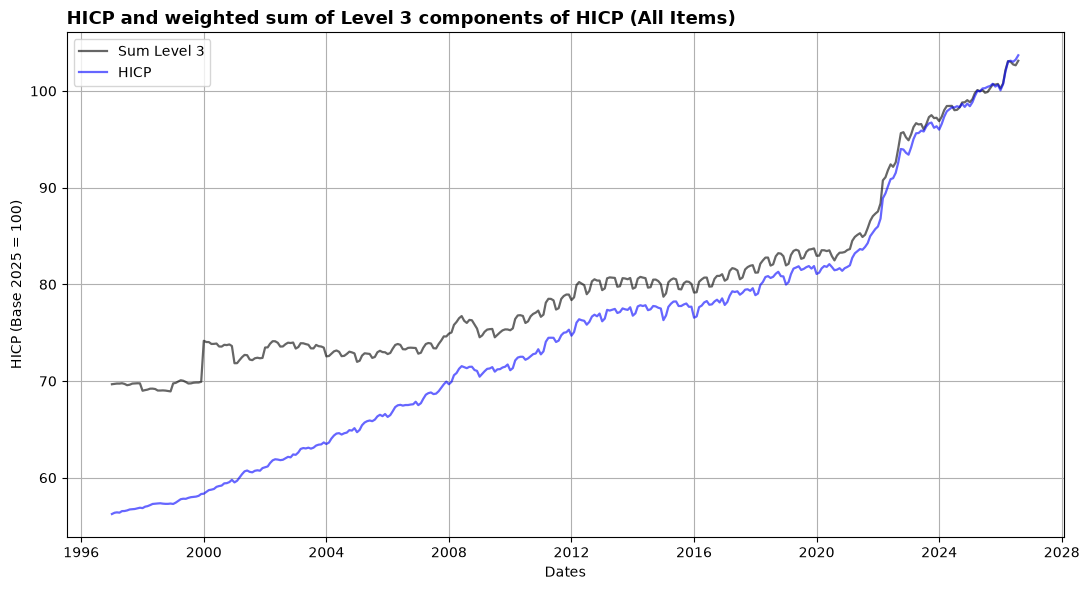

In [314]:
# Comparaison
Niv0 = Niv0[Niv0.index.year >= startYear]

# Plot...
fig, ax = plt.subplots(figsize=(11, 6))

x_axis = hicp.index

ax.plot(x_axis, hicp.values, color="black", lw=1.6, alpha=0.6, label=f"Sum Level {niv}")
ax.plot(x_axis, Niv0.values, color="blue", lw=1.6, alpha=0.6, label="HICP")

# ax.plot(x_axis, dFinal.loc[dFinal.ecoicop == "00", "wINX"].values, color="#4C72B0", lw=1.6, ls="--", label=f"Level 0")
ax.set_title(f"HICP and weighted sum of Level {niv} components of HICP (All Items)",
              fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Dates")
ax.set_ylabel("HICP (Base 2025 = 100)")
ax.legend(loc="best", fontsize=10)
plt.grid()
plt.tight_layout()
plt.show()

In [309]:
# # Chain linked aggregate components
# def chain_link_aggregate(df, code_col, parent_col,
#                           weight_col="WEIGHTS", index_col="INX",
#                           time_col="TIME_PERIOD", base_value=100):
#     df = df.copy()
#     df[time_col] = pd.to_datetime(df[time_col])

#     # --- Step 1 : We unchain the series by dividing each month value by the index value of the previous december ---
#     dec_values = (
#             df[df[time_col].dt.month == 12]
#             .assign(dec_year=lambda d: d[time_col].dt.year)
#             )
#     df['prev_year'] = df[time_col].dt.year - 1
#     df = df.merge(dec_values, left_on='prev_year',
#                    right_on='dec_year', how='left')
#     df['unchained'] = df[index_col] / df['dec_value']

#     # --- Étape 2 : moyenne arithmétique pondérée, par période et par parent ---
#     def _weighted_mean(g):
#         g = g.dropna(subset=['unchained'])
#         return (g[weight_col] * g['unchained']).sum() / g[weight_col].sum()

#     agg = (
#         df.groupby([parent_col, time_col])
#         .apply(_weighted_mean)
#         .reset_index(name='unchained_agg')
#     )

#     # --- Étape 3 : re-chaîner (nécessairement séquentiel, année après année) ---
#     agg = agg.sort_values([parent_col, time_col])
#     agg['year'] = agg[time_col].dt.year
#     agg['is_dec'] = agg[time_col].dt.month == 12

#     resultats = []
#     for parent, g in agg.groupby(parent_col):
#         g = g.sort_values(time_col).reset_index(drop=True)
#         dec_chained = {g['year'].min() - 1: base_value}  # ancre de départ

#         vals = []
#         for _, row in g.iterrows():
#             prev_dec_val = dec_chained.get(row['year'] - 1, base_value)
#             val = row['unchained_agg'] * prev_dec_val
#             vals.append(val)
#             if row['is_dec']:
#                 dec_chained[row['year']] = val

#         g['HICP_chained'] = vals
#         resultats.append(g)

#     return pd.concat(resultats, ignore_index=True)

In [310]:
groupes = dFinal[dFinal['Level'] == 2]
division_result = chain_link_aggregate(groupes, code_col='group', parent_col='div')
division_result[['div', 'TIME_PERIOD', 'HICP_chained']]

NameError: name 'chain_link_aggregate' is not defined

In [ ]:
dFinal[["KEY", "TITLE", "ICP_ITEM", "div", "group", "class", "ssclass", "pos", "Level"]].drop_duplicates()

,KEY,TITLE,ICP_ITEM,div,group,class,ssclass,pos,Level
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,000000,000000,000000,000000,000000,0
440,HICP.M.U2.N.010000.4D0.INX,HICP Inflation rate - Food and non-alcoholic b...,010000,010000,010000,010000,010000,010000,1
808,HICP.M.U2.N.011000.4D0.INX,HICP Inflation rate - Food - Index,011000,010000,011000,011000,011000,011000,2
1176,HICP.M.U2.N.011100.4D0.INX,HICP Inflation rate - Cereals and cereal produ...,011100,010000,011000,011100,011100,011100,3
1544,HICP.M.U2.N.011110.4D0.INX,HICP Inflation rate - Cereals (ND) - Index,011110,010000,011000,011100,011110,011110,4
...,...,...,...,...,...,...,...,...,...
110446,HICP.M.U2.N.XEFUN0.4D0.INX,HICP Inflation rate - Total excluding energy a...,XEFUN0,XE0000,XEF000,XEFU00,XEFUN0,XEFUN0,Other
110814,HICP.M.U2.N.XESEAS.4D0.INX,HICP Inflation rate - Total excluding energy a...,XESEAS,XE0000,XES000,XESE00,XESEA0,XESEAS,Other
111182,HICP.M.U2.N.XFROOP.4D0.INX,HICP Inflation rate - Total excluding frequent...,XFROOP,XF0000,XFR000,XFRO00,XFROO0,XFROOP,Other
111550,HICP.M.U2.N.XFUELL.4D0.INX,HICP Inflation rate - Total excluding liquid f...,XFUELL,XF0000,XFU000,XFUE00,XFUEL0,XFUELL,Other


### Clean merged database
Weights are revised once per year, hence we keep them fixed from January N to Dec N included and weight the HICP components as such. Moreover, all data is not available on the same time window ; we arbitrate between the more granular level of information and the longest timeframe. 

In [ ]:
# Forward fill the weights
dFinal['WEIGHTS'].ffill(inplace=True)
dFinal

/var/folders/zg/2lsdtr0j4fq844zjvs8ybwfc0000gn/T/ipykernel_25935/1252603829.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dFinal['WEIGHTS'].ffill(inplace=True)


,KEY,TITLE,ICP_ITEM,TIME_PERIOD,INX,WEIGHTS,Niveau
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-01-01,NaN,NaN,Niveau 5
1,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-02-01,NaN,NaN,Niveau 5
2,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-03-01,NaN,NaN,Niveau 5
3,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-04-01,NaN,NaN,Niveau 5
4,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,000000,1990-05-01,NaN,NaN,Niveau 5
...,...,...,...,...,...,...,...
111824,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-03-01,101.93,974.55,Other
111825,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-04-01,102.96,974.55,Other
111826,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-05-01,103.08,974.55,Other
111827,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,XSEAS0,2026-06-01,103.03,974.55,Other


In [ ]:
# Data availability
resume = dFinal.groupby(["Niveau","TITLE"]).agg(
    date_min=("TIME_PERIOD", "min"),
    date_max=("TIME_PERIOD", "max"),
    nb_obs_inx=("INX", "count"),
    nb_obs_weights=("WEIGHTS", "count")
).reset_index()
resume

,Niveau,TITLE,date_min,date_max,nb_obs_inx,nb_obs_weights
0,Niveau 5,HICP Inflation rate - Accessories for personal...,2016-12-01,2026-07-01,116,116
1,Niveau 5,HICP Inflation rate - Accessories for photogra...,2016-12-01,2026-07-01,116,116
2,Niveau 5,HICP Inflation rate - Accommodation services (...,1996-01-01,2026-07-01,367,367
3,Niveau 5,HICP Inflation rate - Accommodation services o...,2016-12-01,2026-07-01,116,116
4,Niveau 5,HICP Inflation rate - Actual rental payments m...,1996-01-01,2026-07-01,212,367
...,...,...,...,...,...,...
459,Other,HICP Inflation rate - Total excluding liquid f...,1996-01-01,2026-07-01,367,367
460,Other,HICP Inflation rate - Total excluding mainly a...,2000-12-01,2026-07-01,308,308
461,Other,HICP Inflation rate - Total excluding seasonal...,1996-01-01,2026-07-01,367,367
462,Other,HICP Inflation rate - Total excluding tobacco ...,1996-01-01,2026-07-01,367,367


In [ ]:
dFinal["SHARE"] = dFinal["WEIGHTS"] / 1000
dFinal["wINX"] =  dFinal["INX"]*dFinal["SHARE"]
dFinal

**Careful :** Several dichotomies ; Ecoicop 1 does not account for the 13th component in the HICP - All Items (Personal care, social protection and miscellaneous goods and services) hence, the weights sum to 1015 (including the 13th component) instead of 1000. Moreover, the weights have been revised in 2015, see the differences in the HICP "fit" before and after the revision. 

In [ ]:
# # Forward fill
# dFinal['WEIGHTS'].ffill(inplace=True)
# dFinal

# Exclude 13th component (ECOICOP 2) : Personal Care, Social Protection, Miscellaneous Goods and Services. Included as of 2026-01.
# dFinal = dFinal[~dFinal["ecoicop"].str.startswith("13")].dropna()

In [ ]:
dFinal.loc[dFinal.TIME_PERIOD == "2025-01-01 00:00:00",["Niveau","TITLE"]].groupby("Niveau").count()

,TITLE
Niveau,
Niveau 0,1
Niveau 1,13
Niveau 2,48
Niveau 3,125
Niveau 4,215
Niveau 5,11


In [ ]:
# Niveau 0 c'est l'HICP Total, doit être composé par le Niveau 1
dfNiv1 = dFinal[dFinal.Niveau == "Niveau 1"].pivot(index="TIME_PERIOD", columns="ecoicop", values="wINX")
wNiv1 = dfNiv1.sum(axis=1)

# Niveau 2
dfNiv2 = dFinal[dFinal.Niveau == "Niveau 2"].pivot(index="TIME_PERIOD", columns="ecoicop", values="wINX")
wNiv2 = dfNiv2.sum(axis=1)


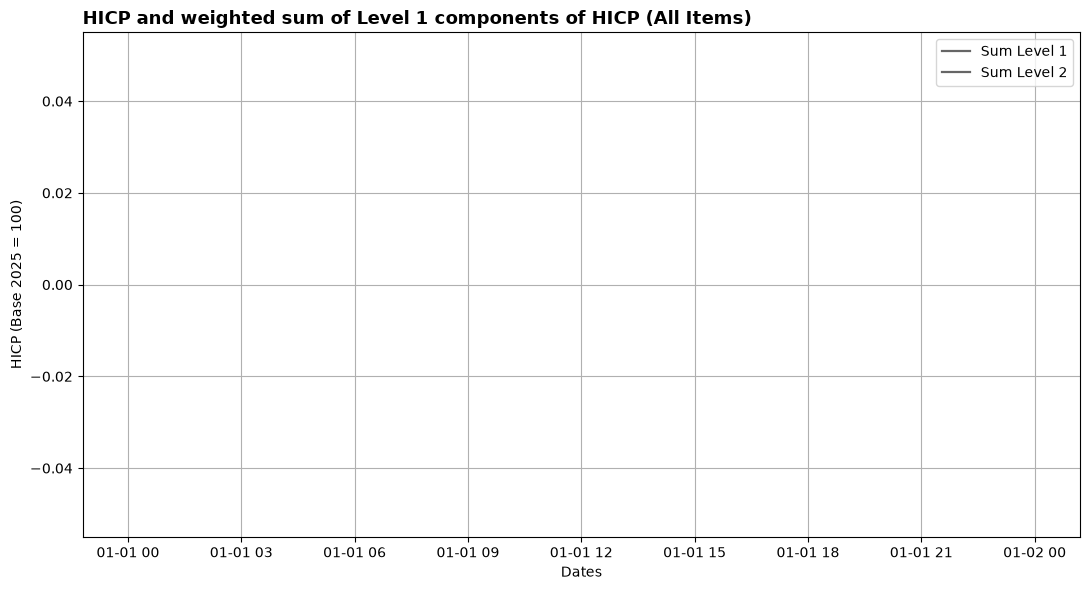

In [ ]:
# Comparaison
# Plot...
fig, ax = plt.subplots(figsize=(11, 6))

x_axis = wNiv1.index

ax.plot(x_axis, wNiv1.values, color="black", lw=1.6, alpha=0.6, label="Sum Level 1")
ax.plot(x_axis, wNiv2.values, color="black", lw=1.6, alpha=0.6, label="Sum Level 2")

# ax.plot(x_axis, dFinal.loc[dFinal.ecoicop == "00", "wINX"].values, color="#4C72B0", lw=1.6, ls="--", label=f"Level 0")
ax.set_title("HICP and weighted sum of Level 1 components of HICP (All Items)",
              fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Dates")
ax.set_ylabel("HICP (Base 2025 = 100)")
ax.legend(loc="best", fontsize=10)
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Create shares, must sum to 1
dFinal["SHARE"] = dFinal["WEIGHTS"]

for i in range(1,len(dFinal.Niveau.unique())):
    col = "Niveau " + i.str()
    mask = (dFinal.Niveau == col)
    
    # Compute shares
    dFinal.loc[mask, "SHARE"] = 


In [ ]:
dFinal.loc[dFinal.Niveau == "Niveau 1", ["TITLE","ecoicop"]].drop_duplicates()

,TITLE,ecoicop
440,HICP Inflation rate - Food and non-alcoholic b...,01
15574,"HICP Inflation rate - Alcoholic beverages, tob...",02
18731,HICP Inflation rate - Clothing and footwear - ...,03
23310,"HICP Inflation rate - Housing, water, electric...",04
31620,"HICP Inflation rate - Furnishings, household e...",05
41126,HICP Inflation rate - Health - Index,06
48408,HICP Inflation rate - Transport - Index,07
58532,HICP Inflation rate - Information and communic...,08
65216,"HICP Inflation rate - Recreation, sport and cu...",09
79703,HICP Inflation rate - Education services - Index,10


In [ ]:
# The sum over Niveau N weights must equal Niveau N-1 weight
df = dFinal[dFinal.Niveau == "Niveau 1"].pivot(index="TIME_PERIOD", columns="ecoicop", values="WEIGHTS")
df.sum(axis=1)

TIME_PERIOD
1996-01-01    1015.57
1996-02-01    1015.57
1996-03-01    1015.57
1996-04-01    1015.57
1996-05-01    1015.57
               ...   
2026-03-01    1015.57
2026-04-01    1015.57
2026-05-01    1015.57
2026-06-01    1015.57
2026-07-01    1015.57
Length: 367, dtype: float64